In [ ]:
import numpy as np
np.set_printoptions(suppress=True, precision=8)

In [ ]:
def par_tacaka_jednacina(pt1, pt2):
  return np.array([
      [0, 0, 0, 0, -pt2[2]*pt1[0], -pt2[2]*pt1[1], -pt2[2]*pt1[2], -pt2[2]*pt1[3], pt2[1]*pt1[0], pt2[1]*pt1[1], pt2[1]*pt1[2], pt2[1]*pt1[3]],
      [pt2[2]*pt1[0], pt2[2]*pt1[1], pt2[2]*pt1[2], pt2[2]*pt1[3], 0, 0, 0, 0, -pt2[0]*pt1[0], -pt2[0]*pt1[1], -pt2[0]*pt1[2], -pt2[0]*pt1[3]]
  ])

In [ ]:
def svd(pts1, pts2):
  jednacine = []
  for i in range(len(pts1)):
    dve = par_tacaka_jednacina(pts1[i], pts2[i])
    jednacine.append(dve[0])
    jednacine.append(dve[1])
  np.array(jednacine)
  U, S, Vh = np.linalg.svd(jednacine)
  matP = Vh[-1].reshape(3,4)
  return matP/matP[2,2]

In [ ]:
p1h = np.array([697,781,1])
p2h = np.array([931,991,1])
p3h = np.array([1202,794,1])
p4h = np.array([637,478,1])
p5h = np.array([910,675,1])
p6h = np.array([1239,484,1])
p7h = np.array([951,331,1])

pp1h = np.array([3, 0, 0, 1])
pp2h = np.array([3, 3, 0, 1])
pp3h = np.array([0, 3, 0, 1])
pp4h = np.array([3, 0, 3, 1])
pp5h = np.array([3, 3, 3, 1])
pp6h = np.array([0, 3, 3, 1])
pp7h = np.array([0, 0, 3, 1])

In [ ]:
def matricaKamera(img, org):
  T = svd(img, org)
  T = T / T[2,3]
  return T

In [ ]:
def kameraInt(T):
  t0 = np.delete(T, 3, 1)
  if (np.linalg.det(t0) < 0):
    t0 = -t0

  t0i = np.linalg.inv(t0)
  Q, R = np.linalg.qr(t0i)
  if (R[0,0] < 0):
    R = np.matmul(np.diag([-1,1,1]), R)
    Q = np.matmul(Q, np.diag([-1,1,1]))

  if (R[1,1] < 0):
    R = np.matmul(np.diag([1,-1,1]), R)
    Q = np.matmul(Q, np.diag([1,-1,1]))

  if (R[2,2] < 0):
    R = np.matmul(np.diag([1,1,-1]), R)
    Q = np.matmul(Q, np.diag([1,1,-1]))

  K = np.linalg.inv(R)
  K = np.where(np.isclose(K, 0), 0.0, K)
  return K / K[2,2]

In [ ]:
def kameraExt(T):
  t0 = np.delete(T, 3, 1)
  if (np.linalg.det(t0) < 0):
    t0 = -t0


  t0i = np.linalg.inv(t0)
  Q, R = np.linalg.qr(t0i)

  if (R[0,0] < 0):
    R = np.matmul(np.diag([-1,1,1]), R)
    Q = np.matmul(Q, np.diag([-1,1,1]))

  if (R[1,1] < 0):
    R = np.matmul(np.diag([1,-1,1]), R)
    Q = np.matmul(Q, np.diag([1,-1,1]))

  if (R[2,2] < 0):
    R = np.matmul(np.diag([1,1,-1]), R)
    Q = np.matmul(Q, np.diag([1,1,-1]))

  A = Q
  A = np.where(np.isclose(A, 0), 0.0, A)
  return np.matrix_transpose(A)

In [ ]:
def centarKamere(T):
  C1 = np.linalg.det(np.delete(T, 0, 1))
  C2 = np.linalg.det(np.delete(T, 1, 1))
  C3 = np.linalg.det(np.delete(T, 2, 1))
  C4 = np.linalg.det(np.delete(T, 3, 1))

  C = (-1/C4) * np.array([C1, -C2, C3, -C4])
  C = np.where(np.isclose(C, 0), 0.0, C)
  return C

In [ ]:
org1 =  np.array([1,-1,-1])*(np.array([2000,0,0]) -  np.array([p1h, p2h, p3h, p4h, p5h, p6h, p7h]))
img1 = np.array([pp1h, pp2h, pp3h, pp4h, pp5h, pp6h, pp7h])

In [ ]:
T = matricaKamera(img1, org1)
print('Matrica kamere:')
print(T)
print()

K = kameraInt(T)
print('Matrica kalibracije kamere:')
print(K)
print()

C = centarKamere(T)
print('Pozicija centra kamere:')
print(centarKamere(T))
print()

A = kameraExt(T)
print('Spoljasna matrica kamere:')
print(A)
print()

Matrica kamere:
[[  46.23220093 -111.77469239  -46.90995074 1039.78550847]
 [  26.26054672   24.49163794 -114.6542591   628.13390036]
 [  -0.03181127   -0.03883821   -0.04771792    1.        ]]

Matrica kalibracije kamere:
[[1540.88660551   -9.21383722 1064.9326371 ]
 [   0.         1555.34604541  768.01978136]
 [   0.            0.            1.        ]]

Pozicija centra kamere:
[7.42538573 8.59064909 9.01429798 1.        ]

Spoljasna matrica kamere:
[[-0.75341559  0.65675219 -0.0322724 ]
 [-0.47055789 -0.50423457  0.72410136]
 [ 0.45928229  0.56073529  0.68893811]]



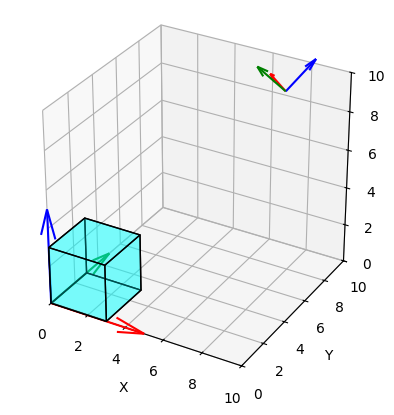

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

cube = np.array([
    [0,0,0], [3,0,0], [3,3,0], [0,3,0],
    [0,0,3], [3,0,3], [3,3,3], [0,3,3]
])

verts = [
    [cube[0], cube[1], cube[2], cube[3]],
    [cube[4], cube[5], cube[6], cube[7]],
    [cube[0], cube[1], cube[5], cube[4]],
    [cube[2], cube[3], cube[7], cube[6]],
    [cube[1], cube[2], cube[6], cube[5]],
    [cube[4], cube[7], cube[3], cube[0]]
]
ax.add_collection3d(Poly3DCollection(verts, facecolors='cyan', linewidths=1, edgecolors='k', alpha=0.3))

scale = 5
origin = np.array([0,0,0])
axes_vectors = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])
for i, vec in enumerate(axes_vectors):
    color = ['r','g','b'][i]
    ax.quiver(origin[0], origin[1], origin[2],
              vec[0], vec[1], vec[2],
              color=color, length=scale)

ax.quiver(C[0], C[1], C[2],
          A[0,0], A[0,1], A[0,2],
          color='r', length=2)

ax.quiver(C[0], C[1], C[2],
          A[1,0], A[1,1], A[1,2],
          color='g', length=2)

ax.quiver(C[0], C[1], C[2],
          A[2,0], A[2,1], A[2,2],
          color='b', length=2)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.set_box_aspect([1,1,1])
ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.set_zlim(0,10)

plt.show()